# Credit Card Application — Full ML Pipeline

## Problem Statement
Predict whether a credit card application will be **approved (1)** or **rejected (0)** based on applicant features.

This is a **binary classification** problem.

## Dataset
- **Source:** UCI Credit Card Approval dataset (anonymised)
- **690 applications**, 14 features + 1 target
- All features are pre-encoded as numbers (original had categorical columns)

| Column | Type | Description |
|--------|------|-------------|
| A1 | Binary (0/1) | Applicant attribute 1 |
| A2 | Float | Applicant attribute 2 |
| A3 | Float | Applicant attribute 3 |
| A4 | Categorical (1-3) | Applicant attribute 4 |
| A5–A14 | Numeric | Remaining applicant attributes |
| **Class** | **0 or 1** | **0 = Rejected, 1 = Approved** |

## ML Pipeline Covered
1. Data Loading & Initial Exploration
2. EDA — Distributions, Correlations, Class Balance
3. Data Preprocessing — Scaling, Train/Test Split
4. Feature Selection — Correlation + SelectKBest
5. Model Training — 9 models (Logistic Regression, Decision Tree, Random Forest, Bagging, AdaBoost, Gradient Boosting, SVM, Voting Ensemble, Stacking)
6. Model Comparison
7. Hyperparameter Tuning — Optuna on the best model
8. Final Evaluation — ROC curve, Confusion Matrix, Classification Report


## Step 1: Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, roc_auc_score, roc_curve,
                              precision_score, recall_score, make_scorer)
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
print('Imports done.')

Imports done.


## Step 2: Load the Dataset

In [4]:
df = pd.read_csv(r'd:\PENDRIVE 32 GB\Game\AI_PROJECTS\Machine Learning\kaggle\Credit_Card_Application\Credit_Card_Applications.csv')
print(f"Shape: {df.shape}")
df.head(10)

Shape: (690, 16)


,CustomerID,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,Class
0,15776156,1,22.08,11.460,2,4,4,1.585,0,0,0,1,2,100,1213,0
1,15739548,0,22.67,7.000,2,8,4,0.165,0,0,0,0,2,160,1,0
2,15662854,0,29.58,1.750,1,4,4,1.250,0,0,0,1,2,280,1,0
3,15687688,0,21.67,11.500,1,5,3,0.000,1,1,11,1,2,0,1,1
4,15715750,1,20.17,8.170,2,6,4,1.960,1,1,14,0,2,60,159,1
5,15571121,0,15.83,0.585,2,8,8,1.500,1,1,2,0,2,100,1,1
6,15726466,1,17.42,6.500,2,3,4,0.125,0,0,0,0,2,60,101,0
7,15660390,0,58.67,4.460,2,11,8,3.040,1,1,6,0,2,43,561,1
8,15663942,1,27.83,1.000,1,2,8,3.000,0,0,0,0,2,176,538,0
9,15638610,0,55.75,7.080,2,4,8,6.750,1,1,3,1,2,100,51,0


### Data Types & Missing Values

In [5]:
print("Data types:")
print(df.dtypes)
print()
print("Missing values:")
print(df.isnull().sum())
print()
print("Data description:")
print(df.describe())
print()
print("Class distribution:")
print(df.shape)
print()
print("Class distribution:")
print(df['Class'].value_counts())
print()
print("Class distribution (percentage):")
print(df['Class'].value_counts(normalize=True) * 100)

Data types:
CustomerID      int64
A1              int64
A2            float64
A3            float64
A4              int64
A5              int64
A6              int64
A7            float64
A8              int64
A9              int64
A10             int64
A11             int64
A12             int64
A13             int64
A14             int64
Class           int64
dtype: object

Missing values:
CustomerID    0
A1            0
A2            0
A3            0
A4            0
A5            0
A6            0
A7            0
A8            0
A9            0
A10           0
A11           0
A12           0
A13           0
A14           0
Class         0
dtype: int64

Data description:
         CustomerID          A1          A2          A3          A4  \
count  6.900000e+02  690.000000  690.000000  690.000000  690.000000   
mean   1.569047e+07    0.678261   31.568203    4.758725    1.766667   
std    7.150647e+04    0.467482   11.853273    4.978163    0.430063   
min    1.556571e+07    0.000000  

### Basic Statistics

In [6]:
df.describe()

,CustomerID,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,Class
count,6.900000e+02,690.000000,690.000000,690.000000,690.000000,690.000000,690.000000,690.000000,690.000000,690.000000,690.00000,690.000000,690.000000,690.000000,690.000000,690.000000
mean,1.569047e+07,0.678261,31.568203,4.758725,1.766667,7.372464,4.692754,2.223406,0.523188,0.427536,2.40000,0.457971,1.928986,184.014493,1018.385507,0.444928
std,7.150647e+04,0.467482,11.853273,4.978163,0.430063,3.683265,1.992316,3.346513,0.499824,0.495080,4.86294,0.498592,0.298813,172.159274,5210.102598,0.497318
min,1.556571e+07,0.000000,13.750000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,1.000000,0.000000,1.000000,0.000000
25%,1.563169e+07,0.000000,22.670000,1.000000,2.000000,4.000000,4.000000,0.165000,0.000000,0.000000,0.00000,0.000000,2.000000,80.000000,1.000000,0.000000
50%,1.569016e+07,1.000000,28.625000,2.750000,2.000000,8.000000,4.000000,1.000000,1.000000,0.000000,0.00000,0.000000,2.000000,160.000000,6.000000,0.000000
75%,1.575190e+07,1.000000,37.707500,7.207500,2.000000,10.000000,5.000000,2.625000,1.000000,1.000000,3.00000,1.000000,2.000000,272.000000,396.500000,1.000000
max,1.581544e+07,1.000000,80.250000,28.000000,3.000000,14.000000,9.000000,28.500000,1.000000,1.000000,67.00000,1.000000,3.000000,2000.000000,100001.000000,1.000000


---
## Step 3: Exploratory Data Analysis (EDA)

EDA helps us understand:
- Class balance (are approvals and rejections equal?)
- Feature distributions (normal? skewed? outliers?)
- Correlations (which features predict approval best?)
- Relationships between features and the target


### 3.1 Class Distribution
Check if the dataset is **balanced** — equal approvals and rejections.
Imbalanced data would require techniques like SMOTE or class_weight adjustments.


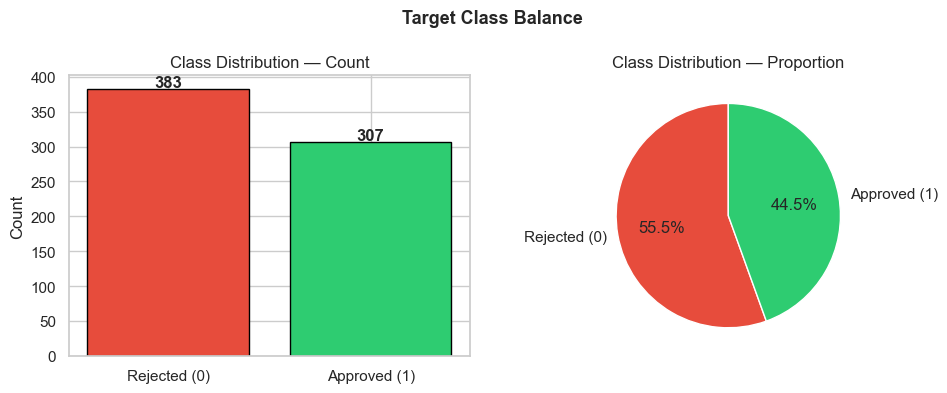

Rejected: 383 (55.5%)
Approved: 307 (44.5%)
Imbalance ratio: 1.25:1


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Count plot
class_counts = df['Class'].value_counts()
axes[0].bar(['Rejected (0)', 'Approved (1)'], class_counts.values,
            color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[0].set_title('Class Distribution — Count')
axes[0].set_ylabel('Count')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 3, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(class_counts.values, labels=['Rejected (0)', 'Approved (1)'],
            colors=['#e74c3c', '#2ecc71'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Class Distribution — Proportion')

plt.suptitle('Target Class Balance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Rejected: {class_counts[0]} ({class_counts[0]/len(df)*100:.1f}%)")
print(f"Approved: {class_counts[1]} ({class_counts[1]/len(df)*100:.1f}%)")
print(f"Imbalance ratio: {class_counts[0]/class_counts[1]:.2f}:1")

### 3.2 Feature Distributions
Histograms for all numeric features — check for skewness and outliers.


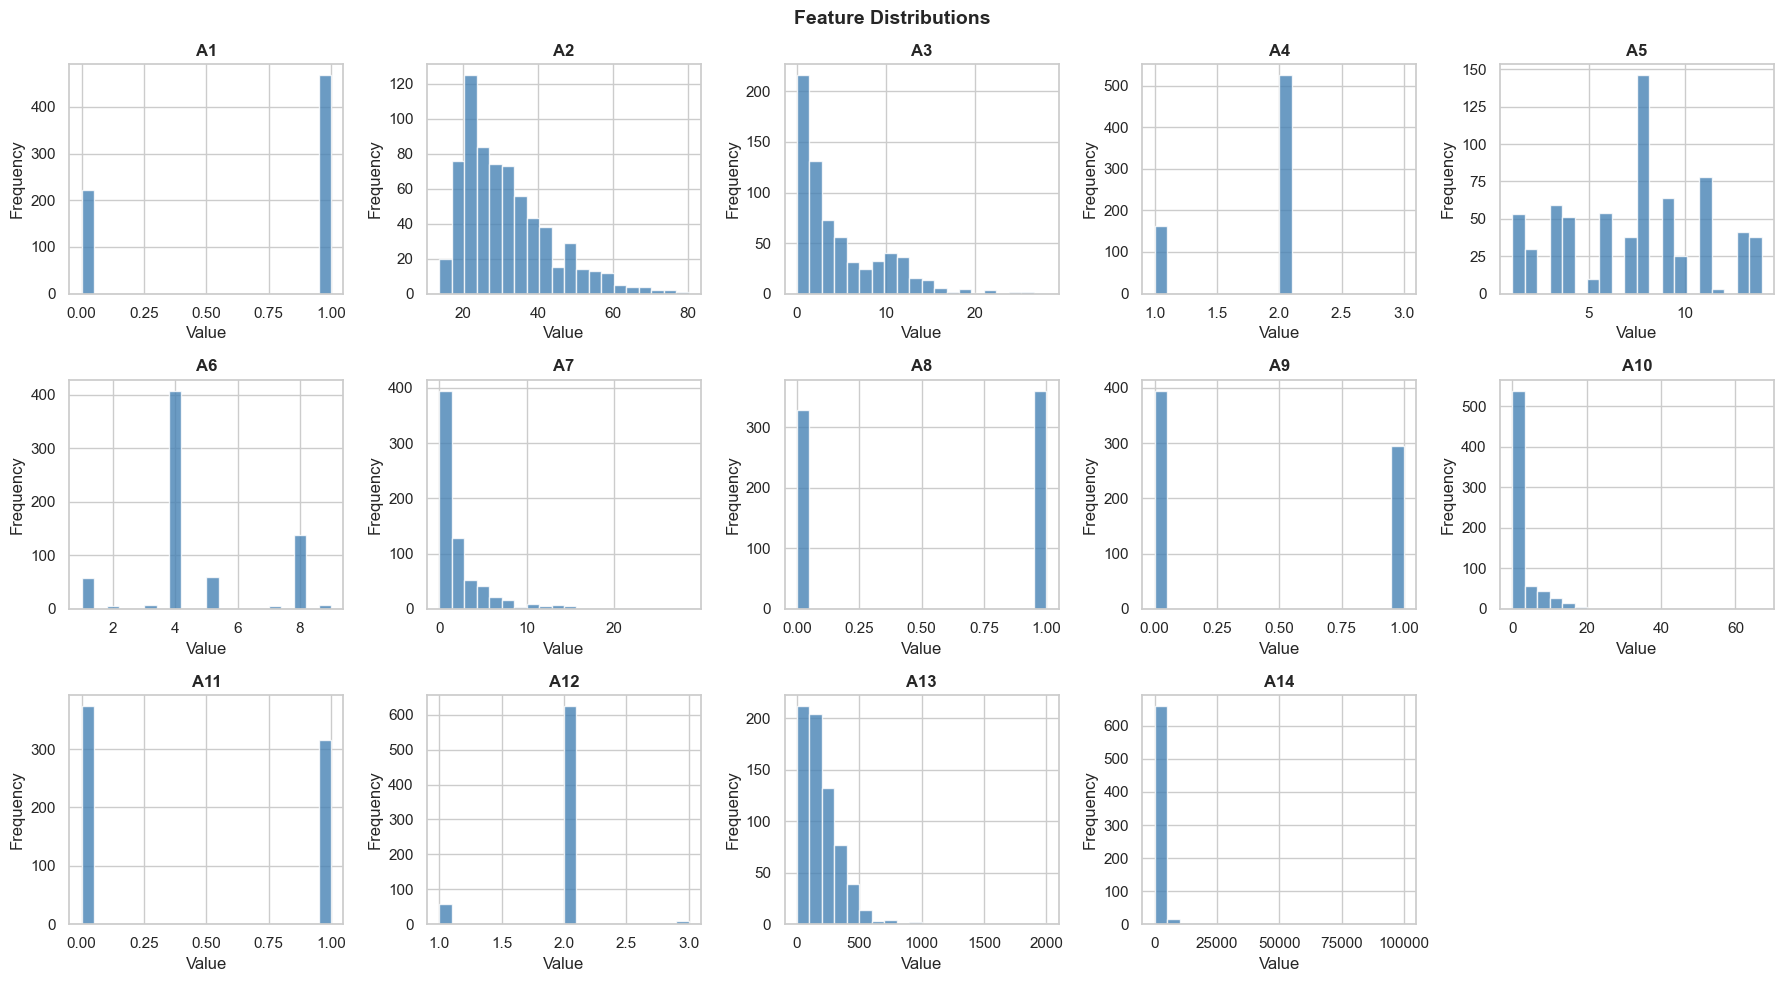

In [8]:
feature_cols = [c for c in df.columns if c not in ['CustomerID', 'Class']]

fig, axes = plt.subplots(3, 5, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    axes[i].hist(df[col], bins=20, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

# Hide any unused subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.3 Feature Distributions by Class
Box plots split by Class — see which features differ most between approved and rejected applications.
A large gap between the two boxes = strong predictor.


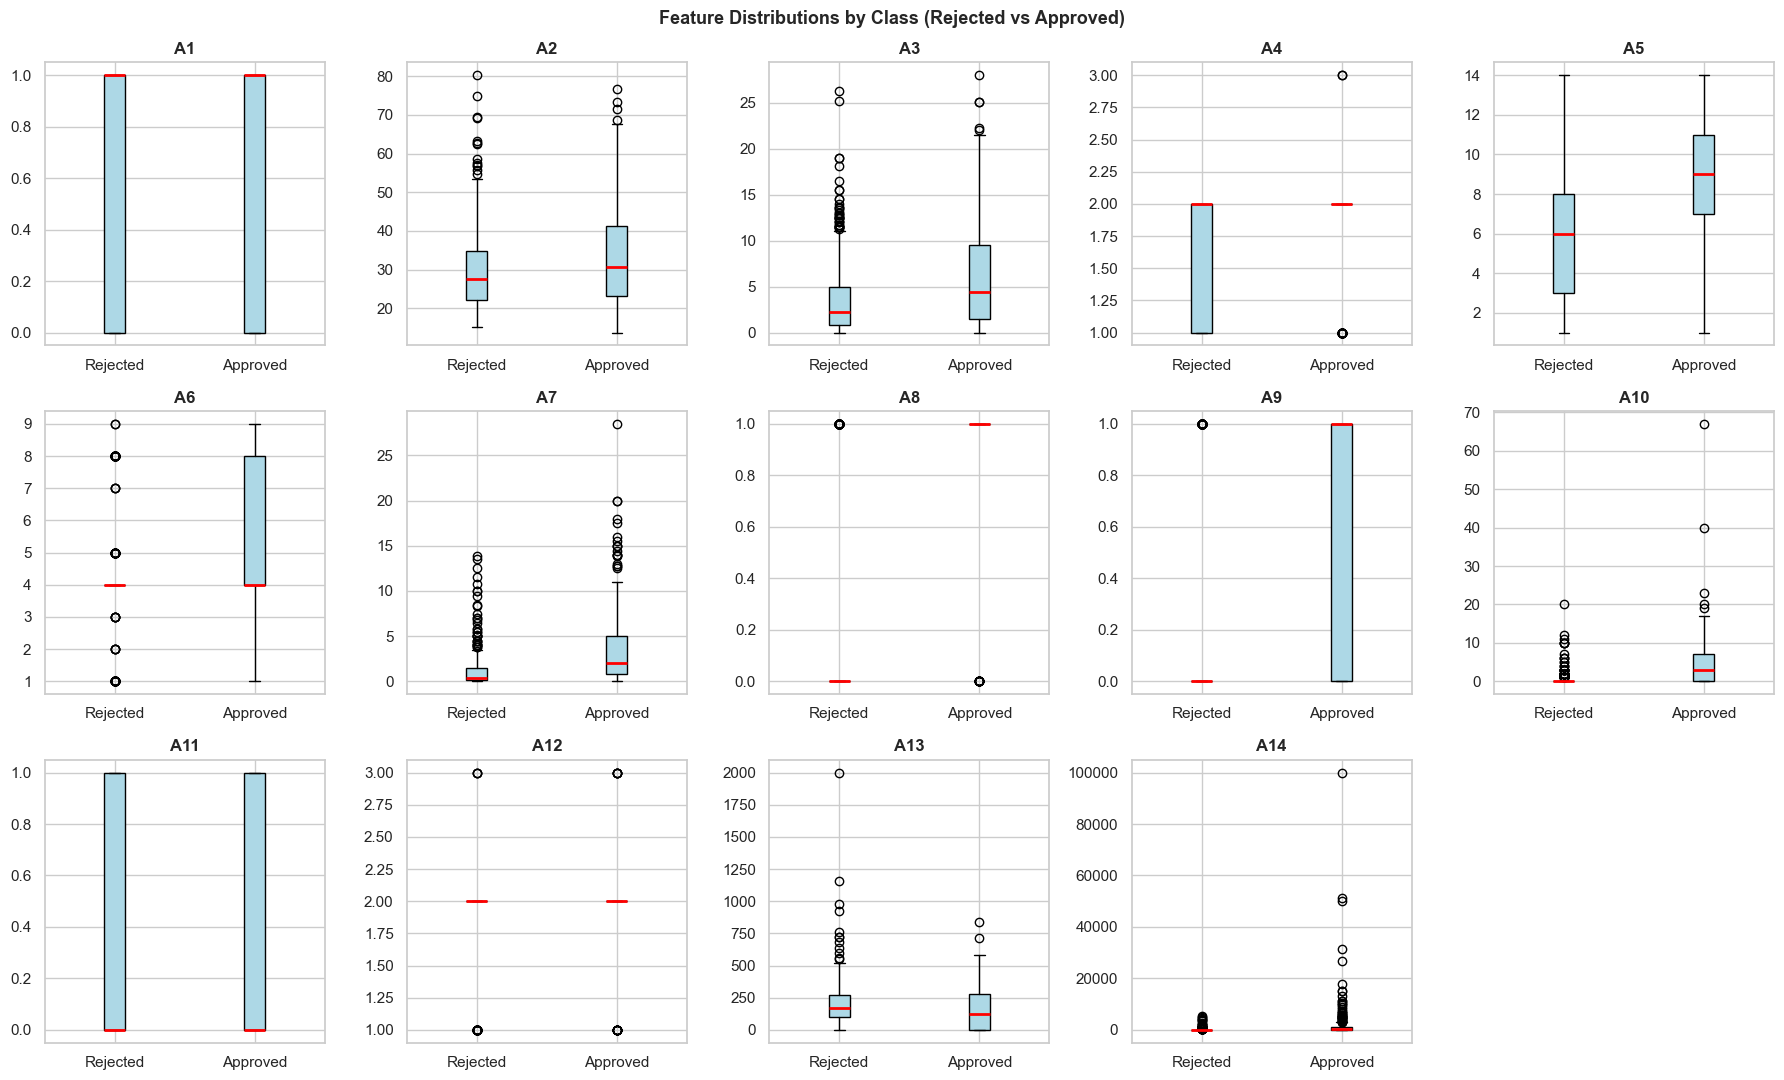

In [9]:
fig, axes = plt.subplots(3, 5, figsize=(18, 11))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    data_0 = df[df['Class'] == 0][col]
    data_1 = df[df['Class'] == 1][col]
    axes[i].boxplot([data_0, data_1], labels=['Rejected', 'Approved'],
                    patch_artist=True,
                    boxprops=dict(facecolor='lightblue'),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col, fontweight='bold')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions by Class (Rejected vs Approved)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# A2 Continuous MildRightSkew Optional transform 
# A3 Continuous ModerateRightSkew Transform 
# A7 Continuous StrongRightSkew Transform
# A13 Continuous RightSkewTransform 
# A14 Continuous ExtremelySkewed Transform
# A10 Count VeryRightSkew Transform 

In [10]:
# ==========================================
# Check Top & Bottom 5% of Skewed Features
# ==========================================

columns = ['A2', 'A3', 'A7', 'A10', 'A13', 'A14']

for col in columns:
    print("=" * 70)
    print(f"{col}")

    # Calculate percentile thresholds
    lower = df[col].quantile(0.05)
    upper = df[col].quantile(0.95)

    print(f"5th Percentile  : {lower:.4f}")
    print(f"95th Percentile : {upper:.4f}")

    # Bottom 5%
    print(f"\nBottom 5% ({len(df[df[col] <= lower])} rows):")
    print(df[df[col] <= lower][col].sort_values().to_string(index=False))

    # Top 5%
    print(f"\nTop 5% ({len(df[df[col] >= upper])} rows):")
    print(df[df[col] >= upper][col].sort_values().to_string(index=False))

    print()


# | Feature | Distribution                      | Extreme values                    | Recommended                             |
# | ------- | --------------------------------- | --------------------------------- | --------------------------------------- |
# | **A2**  | Mild right skew                   | No extreme outliers               | **Leave as is** or optional Yeo-Johnson |
# | **A3**  | Moderate right skew               | Natural spread                    | **log1p** or **Yeo-Johnson**            |
# | **A7**  | Strong right skew with many zeros | Legitimate values                 | **log1p**                               |
# | **A10** | Count variable, many zeros        | Legitimate counts                 | **log1p**, don't trim                   |
# | **A13** | Continuous, long tail             | A few extreme values (1160, 2000) | **Cap or log1p**                        |
# | **A14** | Extremely long tail               | Very large values (50001, 100001) | **Cap/Winsorize + log1p**               |

A2
5th Percentile  : 17.9560
95th Percentile : 56.2310

Bottom 5% (35 rows):
13.75
15.17
15.75
15.83
15.83
15.92
16.00
16.00
16.08
16.08
16.17
16.25
16.25
16.33
16.33
16.33
16.50
16.50
16.92
16.92
17.08
17.08
17.08
17.25
17.33
17.42
17.50
17.58
17.58
17.67
17.67
17.83
17.92
17.92
17.92

Top 5% (35 rows):
56.42
56.50
56.58
56.75
56.83
57.08
57.08
57.42
57.58
57.83
58.33
58.42
58.58
58.67
59.50
59.67
60.08
60.58
60.92
62.50
62.75
63.33
64.08
64.08
65.17
65.42
67.75
68.67
69.17
69.50
71.58
73.42
74.83
76.75
80.25

A3
5th Percentile  : 0.1650
95th Percentile : 14.0000

Bottom 5% (39 rows):
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.000
0.040
0.040
0.040
0.040
0.040
0.080
0.085
0.125
0.125
0.125
0.125
0.125
0.165
0.165
0.165
0.165
0.165
0.165
0.165
0.165

Top 5% (36 rows):
14.000
14.000
14.500
14.500
14.500
14.585
14.790
15.000
15.000
15.000
15.000
15.000
15.000
15.500
15.500
16.000
16.165
16.500
16.500
17.750
18.125
18.500


### 3.4 Correlation Heatmap
Shows linear relationships between all features and the target.
- **+1** = perfect positive correlation
- **-1** = perfect negative correlation
- **0** = no linear relationship

Features strongly correlated with `Class` are the most useful predictors.


Correlation Matrix:
         A1    A2    A3    A4    A5    A6    A7    A8    A9   A10   A11   A12  \
A1     1.00  0.04 -0.03 -0.06 -0.01  0.05  0.10  0.00 -0.06 -0.01  0.05 -0.06   
A2     0.04  1.00  0.20  0.09 -0.09  0.03  0.39  0.20  0.08  0.19  0.05  0.02   
A3    -0.03  0.20  1.00  0.09  0.03  0.09  0.30  0.24  0.17  0.27 -0.01  0.09   
A4    -0.06  0.09  0.09  1.00  0.09  0.05  0.08  0.13  0.16  0.11  0.00  0.01   
A5    -0.01 -0.09  0.03  0.09  1.00  0.40  0.14  0.31  0.22  0.15  0.02  0.07   
A6     0.05  0.03  0.09  0.05  0.40  1.00  0.24  0.25  0.08  0.10  0.09  0.04   
A7     0.10  0.39  0.30  0.08  0.14  0.24  1.00  0.35  0.22  0.32  0.14 -0.02   
A8     0.00  0.20  0.24  0.13  0.31  0.25  0.35  1.00  0.43  0.38  0.09  0.05   
A9    -0.06  0.08  0.17  0.16  0.22  0.08  0.22  0.43  1.00  0.57  0.02  0.18   
A10   -0.01  0.19  0.27  0.11  0.15  0.10  0.32  0.38  0.57  1.00  0.01  0.10   
A11    0.05  0.05 -0.01  0.00  0.02  0.09  0.14  0.09  0.02  0.01  1.00 -0.04   
A12   -0

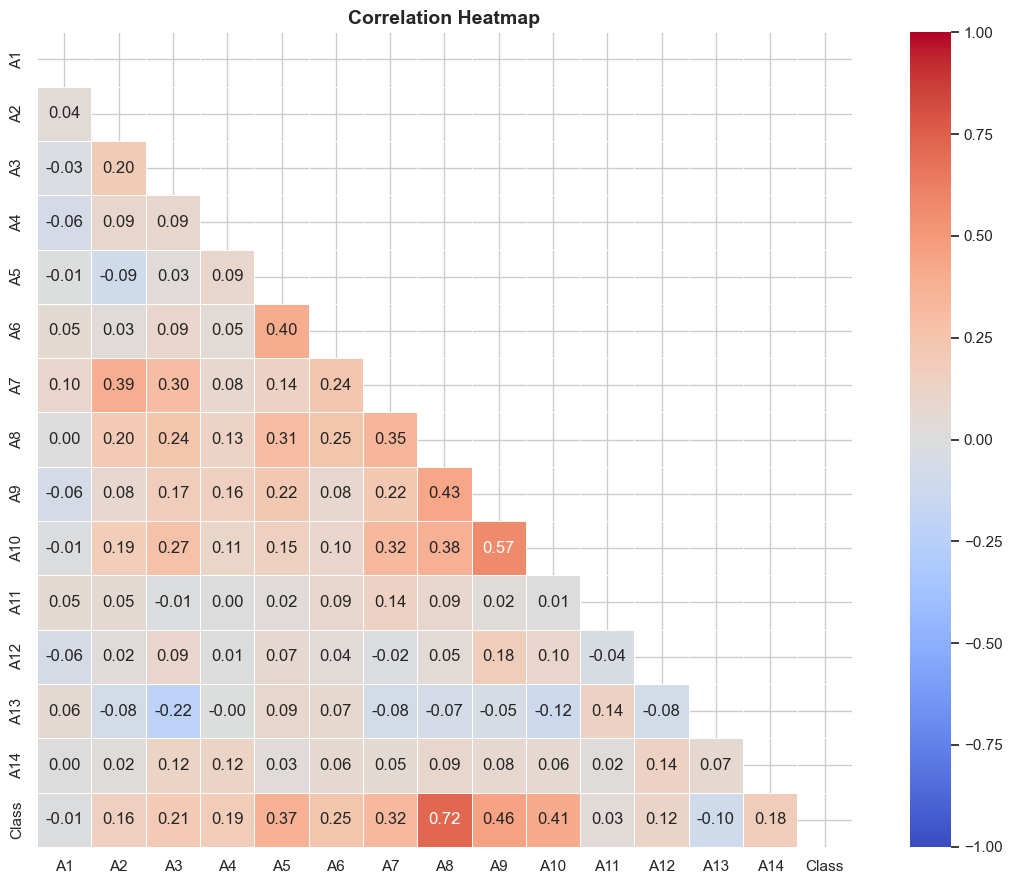

In [11]:
# Correlation matrix
corr = df.drop('CustomerID', axis=1).corr()

# Print correlation values
print("Correlation Matrix:")
print(corr.round(2))   # Round to 2 decimal places

# Heatmap
plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5
)

plt.title('Correlation Heatmap', fontsize=14, fontweight='bold') 
plt.tight_layout() 
plt.show()

# A1, A11 Not Needed

### 3.5 Feature Correlation with Target
Bar chart showing each feature's correlation with `Class` — sorted by importance.


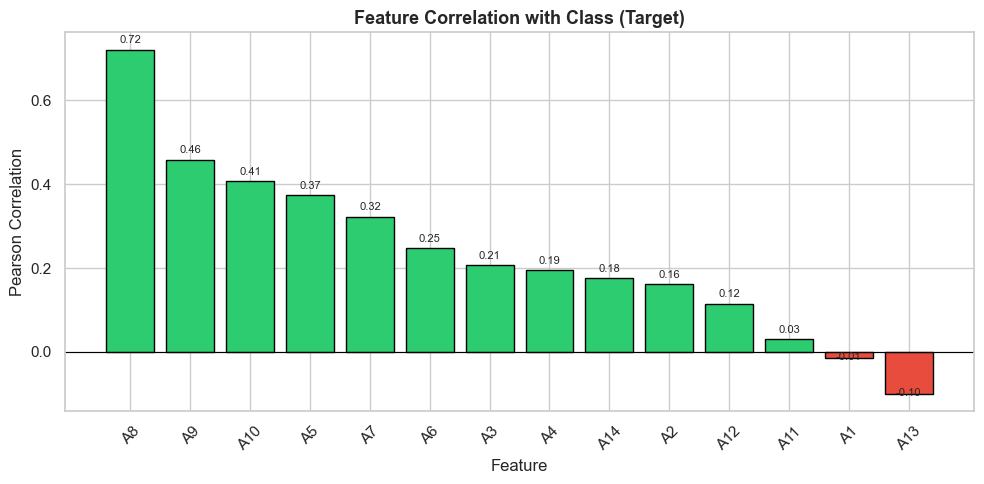

Top 5 positively correlated features:
A8     0.720407
A9     0.458301
A10    0.406410
A5     0.373712
A7     0.322475
Name: Class, dtype: float64

Top 5 negatively correlated features:
A2     0.161626
A12    0.115261
A11    0.031625
A1    -0.013897
A13   -0.099972
Name: Class, dtype: float64


In [12]:
corr_with_target = df.drop('CustomerID', axis=1).corr()['Class'].drop('Class').sort_values(ascending=False)

plt.figure(figsize=(10, 5))
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in corr_with_target.values]
bars = plt.bar(corr_with_target.index, corr_with_target.values, color=colors, edgecolor='black')
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Feature Correlation with Class (Target)', fontsize=13, fontweight='bold')
plt.xlabel('Feature')
plt.ylabel('Pearson Correlation')
plt.xticks(rotation=45)
for bar, val in zip(bars, corr_with_target.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01 * np.sign(val),
             f'{val:.2f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

print("Top 5 positively correlated features:")
print(corr_with_target.head())
print("\nTop 5 negatively correlated features:")
print(corr_with_target.tail())

# A1, A11 Not Needed
# A12, A13 Need to Test Before Removal 

---
## Step 4: Data Preprocessing

### What We Do Here
1. **Drop CustomerID** — just an identifier, no predictive value
2. **Separate features (X) and target (y)**
3. **Train/Test Split** — 80% train, 20% test (stratified to preserve class ratio)
4. **Skew correction** — log1p on A3/A7/A10, winsorize (cap at 99th percentile) + log1p on A13/A14 — thresholds are fit on the training split only, then applied to test, so no test-set information leaks into the transform
5. **StandardScaler** — normalise all features to mean=0, std=1

### Why Scale?
- Distance-based models (SVM, KNN) are very sensitive to feature scale
- Gradient-based models (Logistic Regression) converge faster
- Tree models (RF, GBM) don't need scaling but it doesn't hurt


A13: capped at 99th percentile = 720.00
A14: capped at 99th percentile = 15012.88


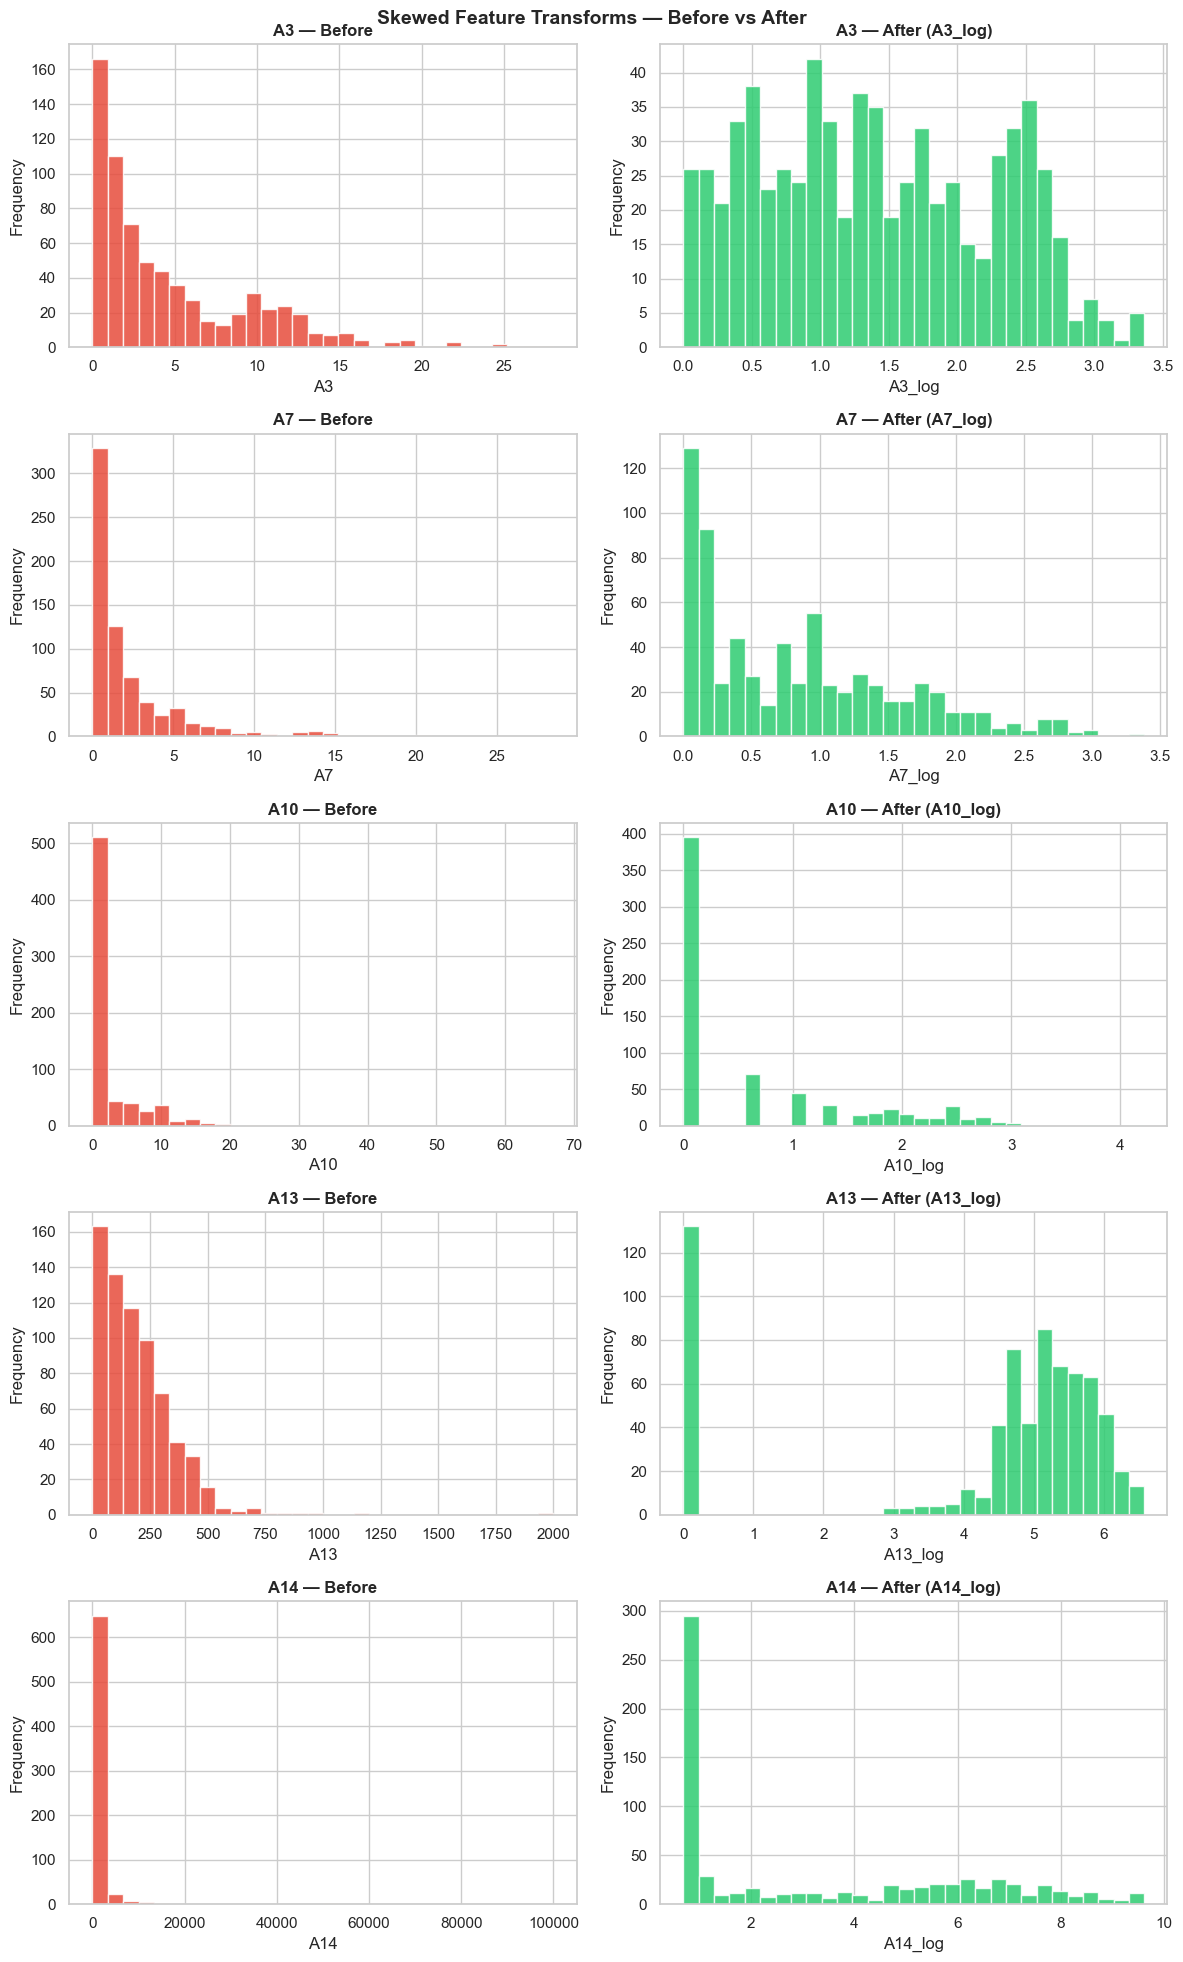


Transformed columns added:
{'A3': 'A3_log', 'A7': 'A7_log', 'A10': 'A10_log', 'A13': 'A13_log', 'A14': 'A14_log'}


In [13]:
# NOTE: this cell is EXPLORATORY ONLY (whole-dataset, pre-split) — it visualises
# what the transforms look like. The actual pipeline transform used for modelling
# is fit on the train split only, inside Step 4 below (no leakage).
# ==========================================
# Apply Transforms Per Feature + Before/After Plots
#
# A3  : Moderate right skew, natural spread          -> log1p
# A7  : Strong right skew, many legitimate zeros      -> log1p
# A10 : Count variable, many legitimate zeros         -> log1p (no trim)
# A13 : Continuous, long tail, a few extreme values   -> cap (winsorize) + log1p
# A14 : Extremely long tail, very large values         -> cap (winsorize) + log1p
# ==========================================

df_transformed = df.copy()

# columns that only need log1p
log1p_cols = ['A3', 'A7', 'A10']

# columns that need capping (winsorize at 99th percentile) before log1p
cap_log_cols = ['A13', 'A14']

transform_map = {}

for col in log1p_cols:
    df_transformed[f'{col}_log'] = np.log1p(df_transformed[col])
    transform_map[col] = f'{col}_log'

for col in cap_log_cols:
    cap_value = df_transformed[col].quantile(0.99)
    df_transformed[f'{col}_capped'] = df_transformed[col].clip(upper=cap_value)
    df_transformed[f'{col}_log'] = np.log1p(df_transformed[f'{col}_capped'])
    transform_map[col] = f'{col}_log'
    print(f"{col}: capped at 99th percentile = {cap_value:.2f}")

# ---- Before / After distribution plots ----
cols_to_plot = log1p_cols + cap_log_cols
fig, axes = plt.subplots(len(cols_to_plot), 2, figsize=(12, 4 * len(cols_to_plot)))

for i, col in enumerate(cols_to_plot):
    transformed_col = transform_map[col]

    axes[i, 0].hist(df[col], bins=30, color='#e74c3c', edgecolor='white', alpha=0.85)
    axes[i, 0].set_title(f'{col} — Before', fontweight='bold')
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Frequency')

    axes[i, 1].hist(df_transformed[transformed_col], bins=30, color='#2ecc71', edgecolor='white', alpha=0.85)
    axes[i, 1].set_title(f'{col} — After ({transformed_col})', fontweight='bold')
    axes[i, 1].set_xlabel(transformed_col)
    axes[i, 1].set_ylabel('Frequency')

plt.suptitle('Skewed Feature Transforms — Before vs After', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nTransformed columns added:")
print(transform_map)

In [14]:
# Drop unnecessary columns
df_clean = df.drop(columns=['CustomerID', 'A1', 'A11'])

# Split into Features (X) and Target (y)
X = df_clean.drop(columns='Class')
y = df_clean['Class']

# Display dataset information
print(f"Remaining Features ({len(X.columns)}):")
print(list(X.columns))

print(f"\nFeature Matrix Shape : {X.shape}")
print(f"Target Shape         : {y.shape}")

print("\nClass Distribution:")
print(y.value_counts().to_dict())

Remaining Features (12):
['A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'A12', 'A13', 'A14']

Feature Matrix Shape : (690, 12)
Target Shape         : (690,)

Class Distribution:
{0: 383, 1: 307}


In [15]:
# Stratified train/test split (preserves class ratio in both sets)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ---- Skew correction (fit on train only, applied to both — no leakage) ----
X_train = X_train.copy()
X_test  = X_test.copy()

log1p_cols   = ['A3', 'A7', 'A10']
cap_log_cols = ['A13', 'A14']

for col in log1p_cols:
    X_train[col] = np.log1p(X_train[col])
    X_test[col]  = np.log1p(X_test[col])

cap_values = {}
for col in cap_log_cols:
    cap_value = X_train[col].quantile(0.99)   # threshold fit on TRAIN only
    cap_values[col] = cap_value
    X_train[col] = np.log1p(X_train[col].clip(upper=cap_value))
    X_test[col]  = np.log1p(X_test[col].clip(upper=cap_value))

print("Winsorize cap values (fit on train only):")
print(cap_values)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Training set:  {X_train_scaled.shape}")
print(f"Test set:      {X_test_scaled.shape}")
print(f"Class split in train: {dict(pd.Series(y_train).value_counts())}")
print(f"Class split in test:  {dict(pd.Series(y_test).value_counts())}")


Winsorize cap values (fit on train only):
{'A13': np.float64(739.6000000000004), 'A14': np.float64(15053.920000000002)}
Training set:  (552, 12)
Test set:      (138, 12)
Class split in train: {0: np.int64(306), 1: np.int64(246)}
Class split in test:  {0: np.int64(77), 1: np.int64(61)}


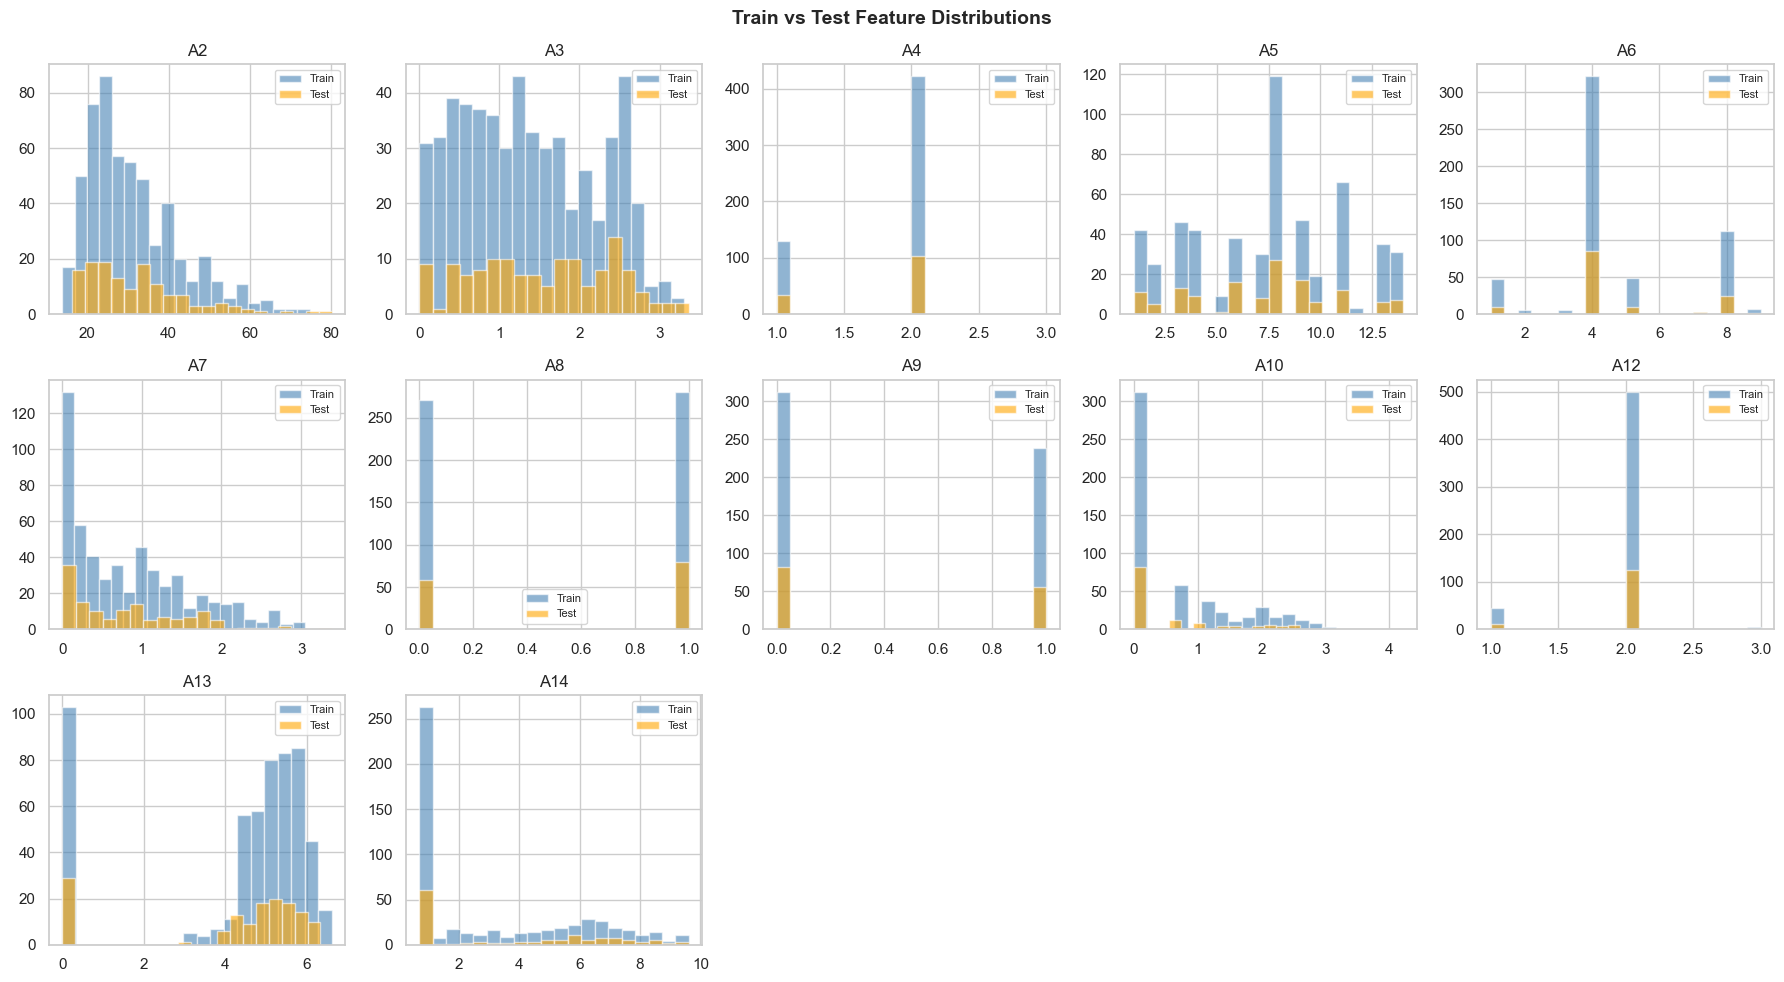

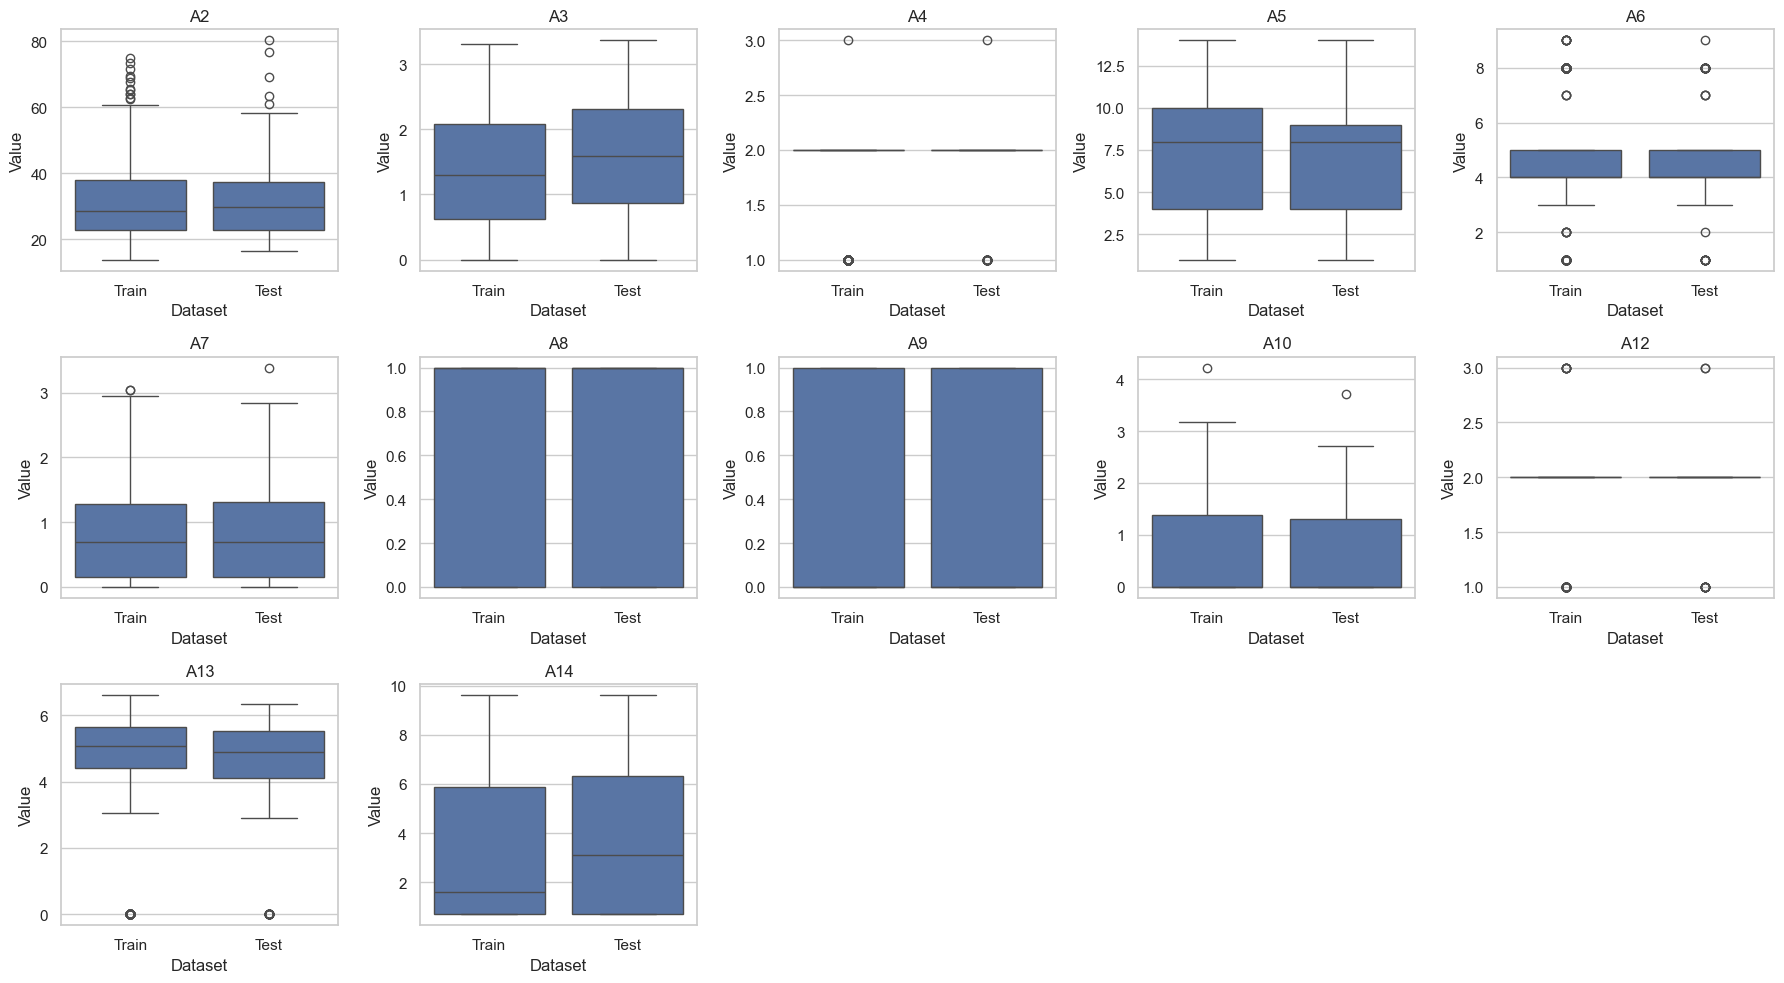

In [16]:
# Feature Distribution
feature_cols = X_train.columns

fig, axes = plt.subplots(3, 5, figsize=(18,10))
axes = axes.flatten()

for i, col in enumerate(feature_cols):

    axes[i].hist(
        X_train[col],
        bins=20,
        alpha=0.6,
        label="Train",
        color="steelblue"
    )

    axes[i].hist(
        X_test[col],
        bins=20,
        alpha=0.6,
        label="Test",
        color="orange"
    )

    axes[i].set_title(col)
    axes[i].legend(fontsize=8)

# Hide empty subplot
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Train vs Test Feature Distributions",
             fontsize=14,
             fontweight="bold")

plt.tight_layout()
plt.show()


# Boxplots
import seaborn as sns
import pandas as pd

fig, axes = plt.subplots(3, 5, figsize=(18,10))
axes = axes.flatten()

for i, col in enumerate(X_train.columns):

    temp = pd.DataFrame({
        "Value": pd.concat([X_train[col], X_test[col]], ignore_index=True),
        "Dataset": ["Train"]*len(X_train) + ["Test"]*len(X_test)
    })

    sns.boxplot(
        data=temp,
        x="Dataset",
        y="Value",
        ax=axes[i]
    )

    axes[i].set_title(col)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

---
## Step 6: Model Training — All Models

### Helper Function
A single `evaluate_model` function runs each model through:
1. 5-fold cross-validation on training data (to check generalisation)
2. Final evaluation on held-out test set
3. ROC-AUC score

We collect all results for comparison at the end.


In [17]:
results = {}

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    # Cross-validation
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X_tr, y_tr, cv=cv, scoring='accuracy')

    # Fit and predict
    model.fit(X_tr, y_tr)
    y_pred  = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else None

    test_acc = accuracy_score(y_te, y_pred)
    auc = roc_auc_score(y_te, y_proba) if y_proba is not None else None

    # Confusion matrix components
    tn, fp, fn, tp = confusion_matrix(y_te, y_pred).ravel()
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec  = recall_score(y_te, y_pred, zero_division=0)

    results[name] = {
        'model':    model,
        'cv_mean':  cv_scores.mean(),
        'cv_std':   cv_scores.std(),
        'test_acc': test_acc,
        'auc':      auc,
        'y_pred':   y_pred,
        'y_proba':  y_proba,
        'fp':        int(fp),
        'precision': prec,
        'recall':    rec,
    }

    print(f"{'='*50}")
    print(f"Model: {name}")
    print(f"  CV Accuracy:   {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print(f"  Test Accuracy: {test_acc:.4f}")
    if auc: print(f"  ROC-AUC:       {auc:.4f}")
    print(f"  Precision:     {prec:.4f}  →  FP = {fp}  (approved when should reject)")
    print()

print('Helper function ready.')

Helper function ready.


### Model 1: Logistic Regression

**Type:** Linear model — draws a straight decision boundary in feature space.

**Key idea:** Applies the sigmoid function to a linear combination of features to output a probability.
```
P(approved) = σ(w₀ + w₁A1 + w₂A2 + ... + w₁₄A14)
```

**Best when:** Features have roughly linear relationships with the target.
**Hyperparameters:** C (inverse regularisation strength), penalty (L1/L2).


In [18]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
evaluate_model('Logistic Regression', lr, X_train_scaled, y_train, X_test_scaled, y_test)

Model: Logistic Regression
  CV Accuracy:   0.8768 ± 0.0095
  Test Accuracy: 0.8261
  ROC-AUC:       0.9070
  Precision:     0.7534  →  FP = 18  (approved when should reject)



### Model 2: Decision Tree

**Type:** Non-linear, rule-based model — splits data on feature thresholds.

**Key idea:** Builds a tree of if-else rules (e.g. "if A8 > 0.5 → approve").
Each split maximises information gain (reduces impurity).

**Strengths:** Interpretable, handles non-linear boundaries.
**Weakness:** Prone to overfitting — deep trees memorise training data.


In [19]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=5, random_state=42)
evaluate_model('Decision Tree', dt, X_train_scaled, y_train, X_test_scaled, y_test)

Model: Decision Tree
  CV Accuracy:   0.8533 ± 0.0206
  Test Accuracy: 0.8043
  ROC-AUC:       0.8604
  Precision:     0.7833  →  FP = 13  (approved when should reject)



### Model 3: Random Forest

**Type:** Bagging ensemble of Decision Trees.

**Key idea:**
1. Bootstrap sample the training data (random rows with replacement)
2. At each split, consider only a random subset of features (random subspaces)
3. Train many trees independently
4. Final prediction = majority vote of all trees

**Why better than one tree:** Averaging many decorrelated trees reduces variance (overfitting).
**Key hyperparameters:** `n_estimators`, `max_depth`, `max_features`.


Model: Random Forest
  CV Accuracy:   0.8787 ± 0.0257
  Test Accuracy: 0.8333
  ROC-AUC:       0.9237
  Precision:     0.7639  →  FP = 17  (approved when should reject)



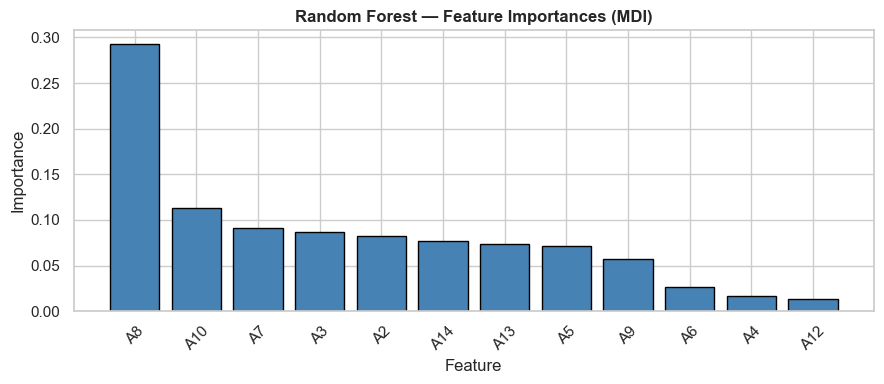

In [20]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, max_depth=None, random_state=42)
evaluate_model('Random Forest', rf, X_train_scaled, y_train, X_test_scaled, y_test)

# Feature importance from Random Forest
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(9, 4))
plt.bar(importances.index, importances.values, color='steelblue', edgecolor='black')
plt.title('Random Forest — Feature Importances (MDI)', fontweight='bold')
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Model 4: Bagging Classifier

**Type:** Generic Bagging ensemble — wraps any base estimator.

**Key idea:** Same as Random Forest bootstrap sampling, but:
- Uses a full Decision Tree (no feature subsampling by default)
- Can wrap any model (Logistic Regression, SVM, etc.)

Random Forest = Bagging + Random Feature Subspace (specialised for trees).


In [21]:
from sklearn.ensemble import BaggingClassifier

bag = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=100, random_state=42)
evaluate_model('Bagging', bag, X_train_scaled, y_train, X_test_scaled, y_test)

Model: Bagging
  CV Accuracy:   0.8787 ± 0.0228
  Test Accuracy: 0.8188
  ROC-AUC:       0.9175
  Precision:     0.7432  →  FP = 19  (approved when should reject)



### Model 5: AdaBoost

**Type:** Boosting ensemble — sequential, adaptive.

**Key idea:**
1. Train a stump (max_depth=1 tree) on the data
2. Misclassified samples get higher weight
3. Next stump focuses on the hard cases
4. Final prediction = weighted vote: `sign(Σ αₜ × Tₜ(x))`

**Key hyperparameters:** `n_estimators` (number of stumps), `learning_rate` (shrinks each stump's weight).


In [22]:
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(n_estimators=100, learning_rate=1.0, random_state=42)
evaluate_model('AdaBoost', ada, X_train_scaled, y_train, X_test_scaled, y_test)

Model: AdaBoost
  CV Accuracy:   0.8588 ± 0.0182
  Test Accuracy: 0.8623
  ROC-AUC:       0.9231
  Precision:     0.8088  →  FP = 13  (approved when should reject)



### Model 6: Gradient Boosting

**Type:** Boosting ensemble — sequential residual fitting.

**Key idea:**
1. Start with mean prediction F₀ = mean(y)
2. Compute residuals r = y - Fₜ
3. Fit a tree Tₜ on the residuals
4. Update: Fₜ₊₁ = Fₜ + lr × Tₜ(x)
5. Repeat N times

**Gradient Boosting vs AdaBoost:**
- AdaBoost: re-weights samples → adapts focus
- Gradient Boosting: fits residuals directly → corrects errors mathematically

**Key hyperparameters:** `n_estimators`, `learning_rate`, `max_depth`.


In [23]:
from sklearn.ensemble import GradientBoostingClassifier

gbc = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
evaluate_model('Gradient Boosting', gbc, X_train_scaled, y_train, X_test_scaled, y_test)

Model: Gradient Boosting
  CV Accuracy:   0.8733 ± 0.0269
  Test Accuracy: 0.8116
  ROC-AUC:       0.9187
  Precision:     0.7536  →  FP = 17  (approved when should reject)



### Model 7: Support Vector Machine (SVM)

**Type:** Margin-based classifier.

**Key idea:** Find the hyperplane that **maximises the margin** between classes.
Support vectors = the data points closest to the boundary (they define it).

**Kernel trick:** Map data to a higher-dimensional space where it becomes linearly separable:
- `linear` — for linearly separable data
- `rbf` (Gaussian) — for non-linear boundaries (most common)
- `poly` — polynomial boundary

**Key hyperparameters:**
- `C` — regularisation (low C = wider margin, more errors allowed)
- `gamma` — RBF kernel width (low = smooth boundary, high = complex)


In [24]:
from sklearn.svm import SVC

svm = SVC(kernel='rbf', C=1.0, probability=True, random_state=42)
evaluate_model('SVM (RBF)', svm, X_train_scaled, y_train, X_test_scaled, y_test)

Model: SVM (RBF)
  CV Accuracy:   0.8787 ± 0.0182
  Test Accuracy: 0.8116
  ROC-AUC:       0.9091
  Precision:     0.7273  →  FP = 21  (approved when should reject)



### Model 8: Voting Ensemble

**Type:** Heterogeneous ensemble — combines different model types.

**Key idea:** Train multiple different models, combine their predictions:
- **Hard voting:** majority vote of predicted classes
- **Soft voting:** average of predicted probabilities → uses confidence, more accurate

**Why better?** Different models have different weaknesses — combining them cancels out individual errors.

Here we combine: Logistic Regression + Random Forest + Gradient Boosting.


In [25]:
from sklearn.ensemble import VotingClassifier

voting = VotingClassifier(
    estimators=[
        ('lr',  LogisticRegression(C=1.0, max_iter=1000, random_state=42)),
        ('rf',  RandomForestClassifier(n_estimators=100, random_state=42)),
        ('gbc', GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)),
    ],
    voting='soft'
)
evaluate_model('Voting Ensemble (soft)', voting, X_train_scaled, y_train, X_test_scaled, y_test)

Model: Voting Ensemble (soft)
  CV Accuracy:   0.8823 ± 0.0231
  Test Accuracy: 0.8116
  ROC-AUC:       0.9265
  Precision:     0.7397  →  FP = 19  (approved when should reject)



### Model 9: Stacking

**Type:** Meta-learning ensemble.

**Key idea:**
- **Level-0 models** (base learners): train on data → output out-of-fold predictions
- **Level-1 model** (meta-learner): trained on the out-of-fold predictions → learns how to best combine the base models

**Why out-of-fold?** Prevents the meta-learner from seeing the training data that the base models were trained on → avoids leakage.

**Architecture here:**
```
Level 0: Logistic Regression, Decision Tree, SVM
           ↓ out-of-fold predictions
Level 1: Random Forest (meta-learner)
```


In [26]:
from sklearn.ensemble import StackingClassifier

stacking = StackingClassifier(
    estimators=[
        ('lr',  LogisticRegression(C=1.0, max_iter=1000, random_state=42)),
        ('dt',  DecisionTreeClassifier(max_depth=5, random_state=42)),
        ('svm', SVC(kernel='rbf', probability=True, random_state=42)),
    ],
    final_estimator=RandomForestClassifier(n_estimators=50, random_state=42),
    cv=5,
    passthrough=False
)
evaluate_model('Stacking', stacking, X_train_scaled, y_train, X_test_scaled, y_test)

Model: Stacking
  CV Accuracy:   0.8642 ± 0.0147
  Test Accuracy: 0.8043
  ROC-AUC:       0.8990
  Precision:     0.7429  →  FP = 18  (approved when should reject)



---
## Step 7: Model Comparison

Compare all 9 models side-by-side on:
- Cross-validation accuracy (training generalisation)
- Test set accuracy (unseen data performance)
- ROC-AUC score (discrimination ability)


In [27]:
# Build comparison table
comparison = pd.DataFrame({
    'Model': list(results.keys()),
    'CV Accuracy': [results[m]['cv_mean'] for m in results],
    'CV Std': [results[m]['cv_std'] for m in results],
    'Test Accuracy': [results[m]['test_acc'] for m in results],
    'ROC-AUC': [results[m]['auc'] for m in results],
}).sort_values('Test Accuracy', ascending=False).reset_index(drop=True)

comparison['CV Accuracy'] = comparison['CV Accuracy'].map('{:.4f}'.format)
comparison['CV Std']      = comparison['CV Std'].map('±{:.4f}'.format)
comparison['Test Accuracy'] = comparison['Test Accuracy'].map('{:.4f}'.format)
comparison['ROC-AUC']     = comparison['ROC-AUC'].map(lambda x: f'{x:.4f}' if x else 'N/A')

print(comparison.to_string(index=False))

                 Model CV Accuracy  CV Std Test Accuracy ROC-AUC
              AdaBoost      0.8588 ±0.0182        0.8623  0.9231
         Random Forest      0.8787 ±0.0257        0.8333  0.9237
   Logistic Regression      0.8768 ±0.0095        0.8261  0.9070
               Bagging      0.8787 ±0.0228        0.8188  0.9175
     Gradient Boosting      0.8733 ±0.0269        0.8116  0.9187
Voting Ensemble (soft)      0.8823 ±0.0231        0.8116  0.9265
             SVM (RBF)      0.8787 ±0.0182        0.8116  0.9091
         Decision Tree      0.8533 ±0.0206        0.8043  0.8604
              Stacking      0.8642 ±0.0147        0.8043  0.8990


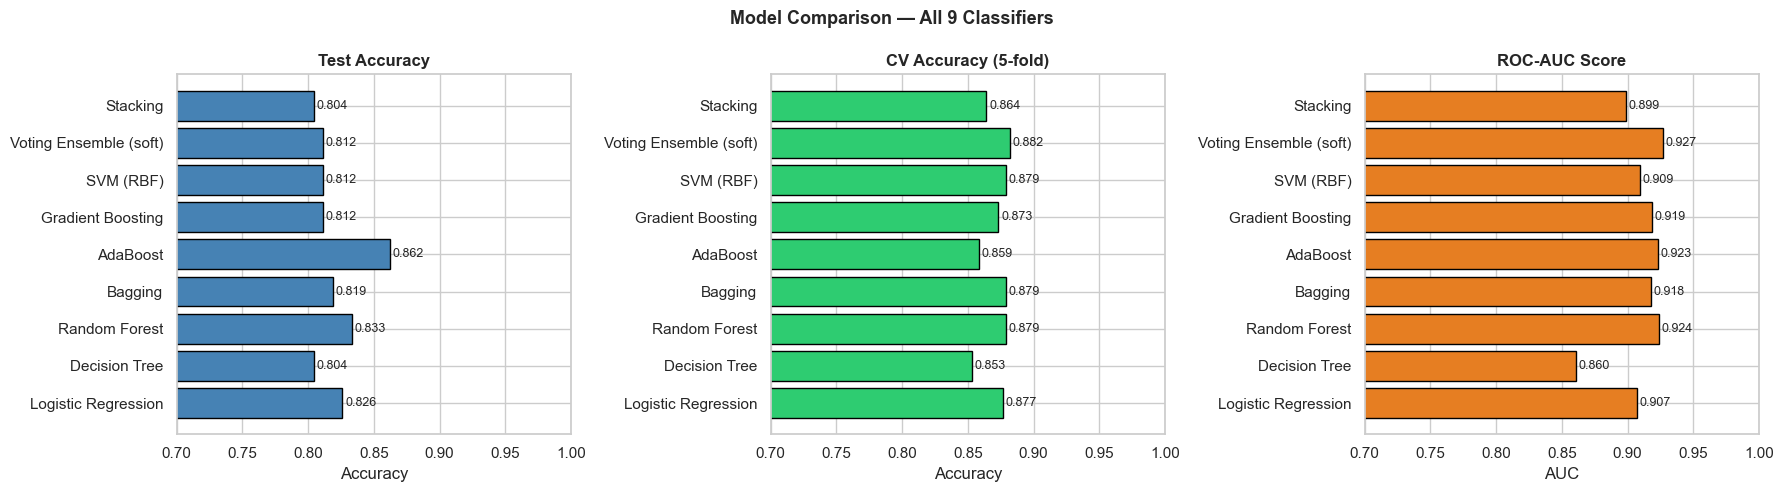

In [28]:
# Visual comparison
model_names = list(results.keys())
test_accs   = [results[m]['test_acc'] for m in model_names]
cv_means    = [results[m]['cv_mean']  for m in model_names]
aucs        = [results[m]['auc']      for m in model_names]

x = range(len(model_names))
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Test Accuracy
bars = axes[0].barh(model_names, test_accs, color='steelblue', edgecolor='black')
axes[0].set_xlim(0.7, 1.0)
axes[0].set_title('Test Accuracy', fontweight='bold')
axes[0].set_xlabel('Accuracy')
for bar, val in zip(bars, test_accs):
    axes[0].text(val + 0.002, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=9)

# CV Accuracy
bars2 = axes[1].barh(model_names, cv_means, color='#2ecc71', edgecolor='black')
axes[1].set_xlim(0.7, 1.0)
axes[1].set_title('CV Accuracy (5-fold)', fontweight='bold')
axes[1].set_xlabel('Accuracy')
for bar, val in zip(bars2, cv_means):
    axes[1].text(val + 0.002, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=9)

# ROC-AUC
bars3 = axes[2].barh(model_names, aucs, color='#e67e22', edgecolor='black')
axes[2].set_xlim(0.7, 1.0)
axes[2].set_title('ROC-AUC Score', fontweight='bold')
axes[2].set_xlabel('AUC')
for bar, val in zip(bars3, aucs):
    axes[2].text(val + 0.002, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=9)

plt.suptitle('Model Comparison — All 9 Classifiers', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Step 8: Hyperparameter Tuning with Optuna — All Models

Instead of tuning only one model, we run an **independent Optuna study (TPE sampler) for every
tunable model** from Step 6, each with its own parameter search space.

### Objective Function: Accuracy + Precision (FP-Aware)

Every trial is scored with a **composite CV score**:

```
Composite = 0.5 × Accuracy + 0.5 × Precision
```

| Metric | What it measures | Why it matters here |
|--------|-----------------|---------------------|
| **Accuracy** | Fraction of correct predictions overall | General model quality |
| **Precision** | TP / (TP + FP) for the Approved class | **Directly penalises False Positives** |

A **False Positive (FP)** = the model approves an applicant who should be rejected.
For a bank, this means lending to a risky customer — potentially a bad debt.
By including Precision in the objective, Optuna actively avoids parameter combinations
that produce too many wrongful approvals.

### Models Tuned & Their Search Spaces

| Model | Parameter | Search Range |
|-------|-----------|-------------|
| **Logistic Regression** | `C` | 1e-3 → 1e2 (log) |
| | `penalty` | l1, l2 |
| **Decision Tree** | `max_depth` | 2 → 20 |
| | `min_samples_split` | 2 → 20 |
| | `min_samples_leaf` | 1 → 10 |
| | `criterion` | gini, entropy |
| **Random Forest** | all DT params + `n_estimators` | 50 → 500 |
| | `max_features` | sqrt, log2, None |
| **Bagging** | `n_estimators` | 20 → 300 |
| | `max_samples`, `max_features` | 0.4 → 1.0 |
| **AdaBoost** | `n_estimators` | 20 → 300 |
| | `learning_rate` | 0.01 → 2.0 (log) |
| **Gradient Boosting** | all above + `subsample` | 0.5 → 1.0 |
| **SVM (RBF)** | `C` | 0.01 → 100 (log) |
| | `gamma` | 1e-4 → 10 (log) |

### Summary Table Columns
- **CV Composite** — best (0.5×Accuracy + 0.5×Precision) seen during search
- **Test Accuracy** — accuracy on held-out test set
- **Precision** — TP/(TP+FP) on test set (higher = fewer wrong approvals)
- **FP Count** — raw False Positive count on the test set (lower is better)
- **ROC-AUC** — area under the ROC curve

In [29]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

N_TRIALS   = 40
tuning_cv  = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Precision scorer: measures TP/(TP+FP) across CV folds.
# High precision = low False Positives = fewer risky applicants wrongly approved.
precision_scorer = make_scorer(precision_score, zero_division=0)

ACCURACY_WEIGHT  = 0.5   # weight for overall accuracy
PRECISION_WEIGHT = 0.5   # weight for precision (penalises False Positives)

def _composite(model):
    """CV composite = 0.5*accuracy + 0.5*precision.  Maximising this raises
    accuracy while simultaneously pushing down False Positives."""
    cv_res = cross_validate(
        model, X_train_scaled, y_train, cv=tuning_cv,
        scoring={'accuracy': 'accuracy', 'precision': precision_scorer},
        error_score=0.0,
    )
    acc  = cv_res['test_accuracy'].mean()
    prec = cv_res['test_precision'].mean()
    return ACCURACY_WEIGHT * acc + PRECISION_WEIGHT * prec


def progress_callback(model_name):
    def _callback(study, trial):
        print(f"  [{model_name}] Trial {trial.number + 1:03d}/{N_TRIALS} "
              f"-> Composite = {trial.value:.4f} | Best = {study.best_value:.4f}")
    return _callback


# ---- Per-model objective functions (all use composite score) ----

def objective_lr(trial):
    params = {
        'C':       trial.suggest_float('C', 1e-3, 1e2, log=True),
        'penalty': trial.suggest_categorical('penalty', ['l1', 'l2']),
    }
    model = LogisticRegression(solver='liblinear', max_iter=1000, random_state=42, **params)
    return _composite(model)


def objective_dt(trial):
    params = {
        'max_depth':         trial.suggest_int('max_depth', 2, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 1, 10),
        'criterion':         trial.suggest_categorical('criterion', ['gini', 'entropy']),
    }
    model = DecisionTreeClassifier(random_state=42, **params)
    return _composite(model)


def objective_rf(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 50, 500),
        'max_depth':         trial.suggest_int('max_depth', 2, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features':      trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
    }
    model = RandomForestClassifier(random_state=42, **params)
    return _composite(model)


def objective_bag(trial):
    params = {
        'n_estimators':  trial.suggest_int('n_estimators', 20, 300),
        'max_samples':   trial.suggest_float('max_samples', 0.4, 1.0),
        'max_features':  trial.suggest_float('max_features', 0.4, 1.0),
    }
    model = BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=42), random_state=42, **params)
    return _composite(model)


def objective_ada(trial):
    params = {
        'n_estimators':  trial.suggest_int('n_estimators', 20, 300),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 2.0, log=True),
    }
    model = AdaBoostClassifier(random_state=42, **params)
    return _composite(model)


def objective_gbc(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 50, 500),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth':         trial.suggest_int('max_depth', 2, 8),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 1, 10),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
    }
    model = GradientBoostingClassifier(random_state=42, **params)
    return _composite(model)


def objective_svm(trial):
    params = {
        'C':     trial.suggest_float('C', 1e-2, 1e2, log=True),
        'gamma': trial.suggest_float('gamma', 1e-4, 1e1, log=True),
    }
    model = SVC(kernel='rbf', probability=True, random_state=42, **params)
    return _composite(model)


# ---- Registry: model name -> (objective function, builder from best params) ----
tuning_registry = {
    'Logistic Regression': (
        objective_lr,
        lambda p: LogisticRegression(solver='liblinear', max_iter=1000, random_state=42, **p)),
    'Decision Tree': (
        objective_dt,
        lambda p: DecisionTreeClassifier(random_state=42, **p)),
    'Random Forest': (
        objective_rf,
        lambda p: RandomForestClassifier(random_state=42, **p)),
    'Bagging': (
        objective_bag,
        lambda p: BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42),
                                     random_state=42, **p)),
    'AdaBoost': (
        objective_ada,
        lambda p: AdaBoostClassifier(random_state=42, **p)),
    'Gradient Boosting': (
        objective_gbc,
        lambda p: GradientBoostingClassifier(random_state=42, **p)),
    'SVM (RBF)': (
        objective_svm,
        lambda p: SVC(kernel='rbf', probability=True, random_state=42, **p)),
}

tuning_studies = {}
tuned_results  = {}

for name, (objective_fn, builder_fn) in tuning_registry.items():
    print('=' * 60)
    print(f'Tuning: {name}  ({N_TRIALS} trials)')
    print(f'Objective: {ACCURACY_WEIGHT}*Accuracy + {PRECISION_WEIGHT}*Precision')
    print('=' * 60)

    study = optuna.create_study(
        direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(
        objective_fn, n_trials=N_TRIALS, callbacks=[progress_callback(name)])
    tuning_studies[name] = study

    print(f'\n  Best Composite Score for {name}: {study.best_value:.4f}')
    print(f'  Best Parameters: {study.best_params}\n')

    tuned_model = builder_fn(study.best_params)
    evaluate_model(f'{name} (Tuned)', tuned_model,
                   X_train_scaled, y_train, X_test_scaled, y_test)

    tuned_results[name] = {
        'cv_best_composite': study.best_value,
        'best_params':       study.best_params,
        'test_acc':          results[f'{name} (Tuned)']['test_acc'],
        'auc':               results[f'{name} (Tuned)']['auc'],
        'fp':                results[f'{name} (Tuned)']['fp'],
        'precision':         results[f'{name} (Tuned)']['precision'],
    }

print('\nAll models tuned.')

Tuning: Logistic Regression  (40 trials)
Objective: 0.5*Accuracy + 0.5*Precision
  [Logistic Regression] Trial 001/40 -> Composite = 0.8385 | Best = 0.8385
  [Logistic Regression] Trial 002/40 -> Composite = 0.8677 | Best = 0.8677
  [Logistic Regression] Trial 003/40 -> Composite = 0.2772 | Best = 0.8677
  [Logistic Regression] Trial 004/40 -> Composite = 0.8667 | Best = 0.8677
  [Logistic Regression] Trial 005/40 -> Composite = 0.8616 | Best = 0.8677
  [Logistic Regression] Trial 006/40 -> Composite = 0.8779 | Best = 0.8779
  [Logistic Regression] Trial 007/40 -> Composite = 0.8733 | Best = 0.8779
  [Logistic Regression] Trial 008/40 -> Composite = 0.8691 | Best = 0.8779
  [Logistic Regression] Trial 009/40 -> Composite = 0.8551 | Best = 0.8779
  [Logistic Regression] Trial 010/40 -> Composite = 0.8602 | Best = 0.8779
  [Logistic Regression] Trial 011/40 -> Composite = 0.8641 | Best = 0.8779
  [Logistic Regression] Trial 012/40 -> Composite = 0.8735 | Best = 0.8779
  [Logistic Regress

Hyperparameter Tuning Summary
              Model  CV Composite  Test Accuracy  Precision  FP Count  ROC-AUC
            Bagging      0.886426       0.840580   0.791045        14 0.929742
  Gradient Boosting      0.878409       0.826087   0.753425        18 0.928465
           AdaBoost      0.874928       0.833333   0.763889        17 0.926017
Logistic Regression      0.879206       0.833333   0.763889        17 0.918459
      Random Forest      0.886820       0.855072   0.805970        13 0.913988
          SVM (RBF)      0.888700       0.826087   0.862745         7 0.911220
      Decision Tree      0.873334       0.833333   0.787879        14 0.903875

Best Tuned Model : Bagging
Best Parameters  : {'n_estimators': 217, 'max_samples': 0.5041729305330257, 'max_features': 0.5543429713815704}
CV Composite     : 0.8864
Test Accuracy    : 0.8406
Precision        : 0.7910
False Positives  : 14
ROC-AUC          : 0.9297


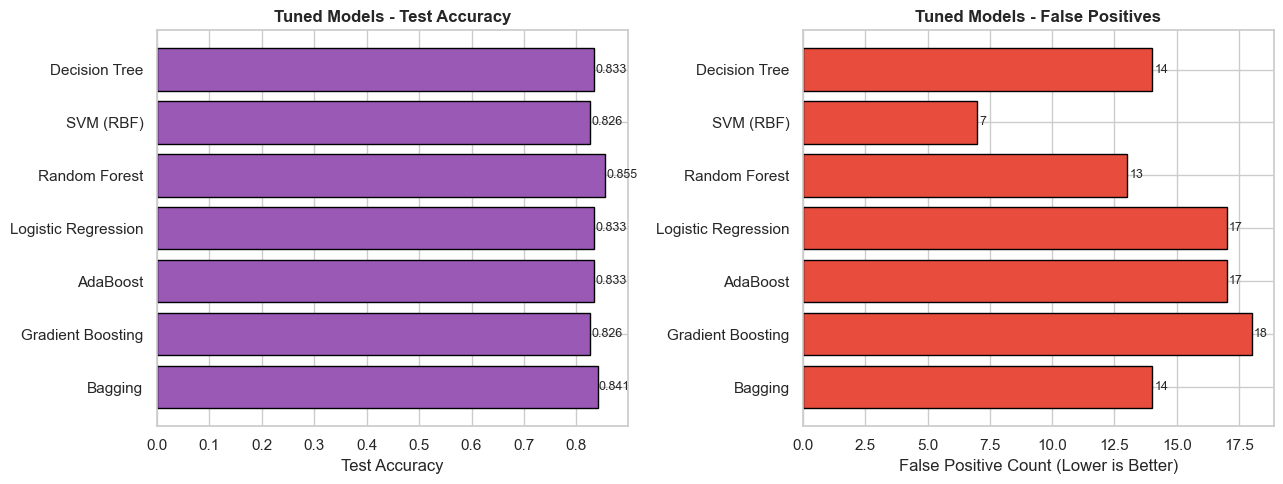


Selection Priority:
1. Highest ROC-AUC
2. Highest Test Accuracy
3. Highest Precision
4. Lowest False Positives


In [ ]:
# ---- Hyperparameter Tuning Summary ----
tuning_summary = pd.DataFrame({
    'Model':            list(tuned_results.keys()),
    'CV Composite':     [tuned_results[m]['cv_best_composite'] for m in tuned_results],
    'Test Accuracy':    [tuned_results[m]['test_acc']          for m in tuned_results],
    'Precision':        [tuned_results[m]['precision']         for m in tuned_results],
    'FP Count':         [tuned_results[m]['fp']                for m in tuned_results],
    'ROC-AUC':          [tuned_results[m]['auc']               for m in tuned_results],
})

# Sort priority:
# 1. Lowest False Positives
# 2. Highest ROC-AUC
# 3. Highest Test Accuracy
# 4. Highest Precision
tuning_summary = tuning_summary.sort_values(
    by=['FP Count', 'ROC-AUC', 'Test Accuracy', 'Precision'],
    ascending=[True, False, False, False]
).reset_index(drop=True)

print("Hyperparameter Tuning Summary")
print(tuning_summary.to_string(index=False))

# ---------------- Best Model ----------------
best_tuned_name = tuning_summary.iloc[0]['Model']
best = tuned_results[best_tuned_name]

print(f"\nBest Tuned Model : {best_tuned_name}")
print(f"Best Parameters  : {best['best_params']}")
print(f"CV Composite     : {best['cv_best_composite']:.4f}")
print(f"Test Accuracy    : {best['test_acc']:.4f}")
print(f"Precision        : {best['precision']:.4f}")
print(f"False Positives  : {best['fp']}")
print(f"ROC-AUC          : {best['auc']:.4f}")

# ---------------- Visualization ----------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Accuracy Chart
bars_acc = axes[0].barh(
    tuning_summary['Model'],
    tuning_summary['Test Accuracy'],
    color='#9b59b6',
    edgecolor='black'
)

axes[0].set_xlabel('Test Accuracy')
axes[0].set_title('Tuned Models - Test Accuracy', fontweight='bold')

for bar, val in zip(bars_acc, tuning_summary['Test Accuracy']):
    axes[0].text(
        val + 0.002,
        bar.get_y() + bar.get_height()/2,
        f'{val:.3f}',
        va='center',
        fontsize=9
    )

# False Positive Chart
bars_fp = axes[1].barh(
    tuning_summary['Model'],
    tuning_summary['FP Count'],
    color='#e74c3c',
    edgecolor='black'
)

axes[1].set_xlabel('False Positive Count (Lower is Better)')
axes[1].set_title('Tuned Models - False Positives', fontweight='bold')

for bar, val in zip(bars_fp, tuning_summary['FP Count']):
    axes[1].text(
        val + 0.1,
        bar.get_y() + bar.get_height()/2,
        str(int(val)),
        va='center',
        fontsize=9
    )

plt.tight_layout()
plt.show()

print("\nSelection Priority:")
print("1. Lowest False Positives")
print("2. Highest ROC-AUC")
print("3. Highest Test Accuracy")
print("4. Highest Precision")

---
## Step 9: Final Model Evaluation

Evaluate the **overall best model** — chosen automatically from every baseline (Step 6) and tuned (Step 8) entry in `results` — on the test set with:
1. **Confusion Matrix** — true/false positives and negatives
2. **Classification Report** — precision, recall, F1 per class
3. **ROC Curve** — all models overlaid for comparison

### Confusion Matrix Explained
```
                  Predicted
                Reject  Approve
Actual Reject  |  TN  |  FP  |   ← False Positives = approved when should reject
       Approve |  FN  |  TP  |   ← False Negatives = rejected when should approve
```
- **High FP** = approving risky applicants (costly for bank)
- **High FN** = rejecting good applicants (lost business)


Best model: SVM (RBF) (Tuned)
Test Accuracy: 0.8261
ROC-AUC:       0.9112


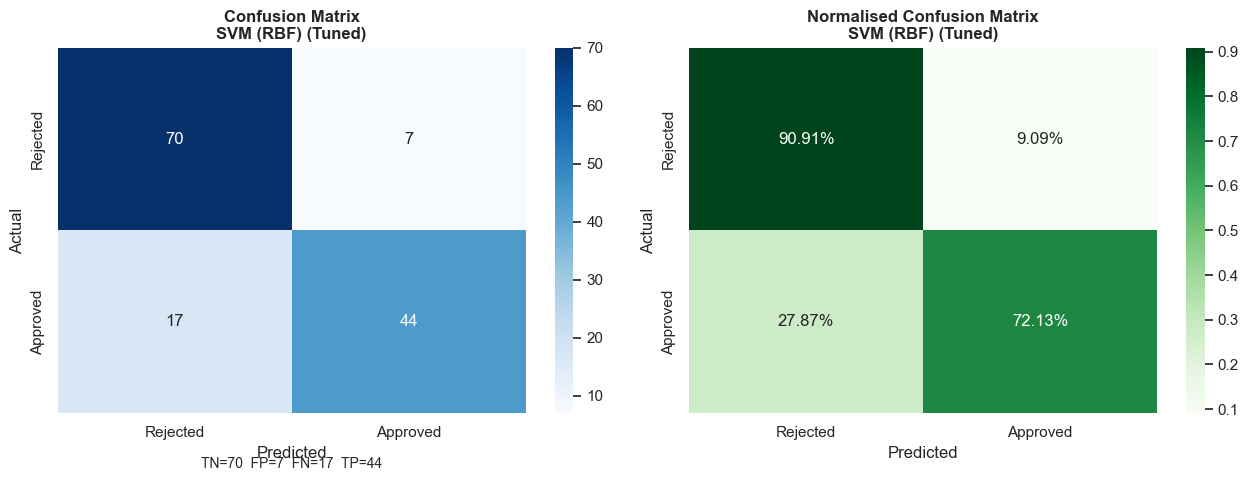

In [46]:
# Pick the best model
best_name = sorted(
    results.keys(),
    key=lambda m: (
        results[m]['fp'],             # Lower is better
        -results[m]['auc'],           # Higher is better
        -results[m]['test_acc'],      # Higher is better
        -results[m]['precision']      # Higher is better
    )
)[0]

best_result = results[best_name]
print(f"Best model: {best_name}")
print(f"Test Accuracy: {best_result['test_acc']:.4f}")
print(f"ROC-AUC:       {best_result['auc']:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, best_result['y_pred'])
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Rejected', 'Approved'],
            yticklabels=['Rejected', 'Approved'])
axes[0].set_title(f'Confusion Matrix\n{best_name}', fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Add labels
tn, fp, fn, tp = cm.ravel()
axes[0].text(0.5, -0.15, f'TN={tn}  FP={fp}  FN={fn}  TP={tp}',
             ha='center', transform=axes[0].transAxes, fontsize=10)

# Normalised confusion matrix
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Greens', ax=axes[1],
            xticklabels=['Rejected', 'Approved'],
            yticklabels=['Rejected', 'Approved'])
axes[1].set_title(f'Normalised Confusion Matrix\n{best_name}', fontweight='bold')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

In [47]:
# Classification Report
print("Classification Report:")
print(classification_report(y_test, best_result['y_pred'],
                             target_names=['Rejected (0)', 'Approved (1)']))

Classification Report:
              precision    recall  f1-score   support

Rejected (0)       0.80      0.91      0.85        77
Approved (1)       0.86      0.72      0.79        61

    accuracy                           0.83       138
   macro avg       0.83      0.82      0.82       138
weighted avg       0.83      0.83      0.82       138



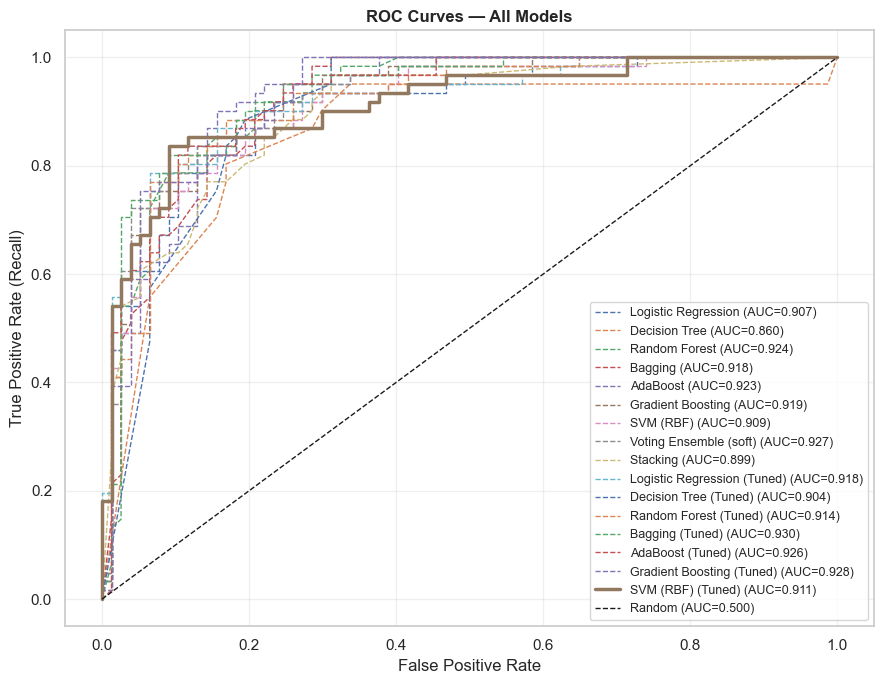

In [48]:
# ROC Curves — all models overlaid
plt.figure(figsize=(9, 7))

for name, res in results.items():
    if res['y_proba'] is not None:
        fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
        auc = res['auc']
        lw = 2.5 if name == best_name else 1.0
        ls = '-' if name == best_name else '--'
        plt.plot(fpr, tpr, linewidth=lw, linestyle=ls,
                 label=f'{name} (AUC={auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC=0.500)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curves — All Models', fontweight='bold')
plt.legend(loc='lower right', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Summary

### Pipeline Recap
```
Raw Data (690 × 16)
    ↓
EDA — class balance, distributions, correlations
    ↓
Preprocessing — drop CustomerID, StandardScaler, 80/20 split
    ↓
Feature Selection — ANOVA F-test (informational)
    ↓
Model Training (9 models):
    Linear:    Logistic Regression
    Tree:      Decision Tree
    Ensemble:  Random Forest, Bagging, AdaBoost, Gradient Boosting
    Kernel:    SVM (RBF)
    Combined:  Voting (soft), Stacking
    ↓
Comparison — Test Accuracy, CV Accuracy, ROC-AUC
    ↓
Hyperparameter Tuning — independent Optuna study per model (40 trials each,
    TPE sampler), Voting/Stacking left at defaults
    ↓
Final Evaluation — best model picked automatically from baseline + tuned results,
    Confusion Matrix, Classification Report, ROC Curve
```

### Key Takeaways
- **Feature A8** (binary) has the highest correlation with approval (r=0.72) — most important predictor
- **Ensemble methods** (RF, GBM, Stacking) generally outperform single models
- Each model is tuned independently with Optuna — the tuning summary table in Step 8 shows which one benefits most and its best hyperparameters
- The dataset is **slightly imbalanced** (56% rejected / 44% approved) — model performs well regardless

### Next Steps
- Try XGBoost / LightGBM for faster gradient boosting
- Apply SHAP values for model explainability
- Deploy the best model with Flask/FastAPI


Best model overall: SVM (RBF) (Tuned)
Test Accuracy: 0.8261
ROC-AUC:       0.9112

Classification Report for Best Model:
              precision    recall  f1-score   support

Rejected (0)       0.80      0.91      0.85        77
Approved (1)       0.86      0.72      0.79        61

    accuracy                           0.83       138
   macro avg       0.83      0.82      0.82       138
weighted avg       0.83      0.83      0.82       138


Confusion Matrix for Best Model:
[[70  7]
 [17 44]]

Normalised Confusion Matrix for Best Model:
[[0.90909091 0.09090909]
 [0.27868852 0.72131148]]

ROC Curve for Best Model:


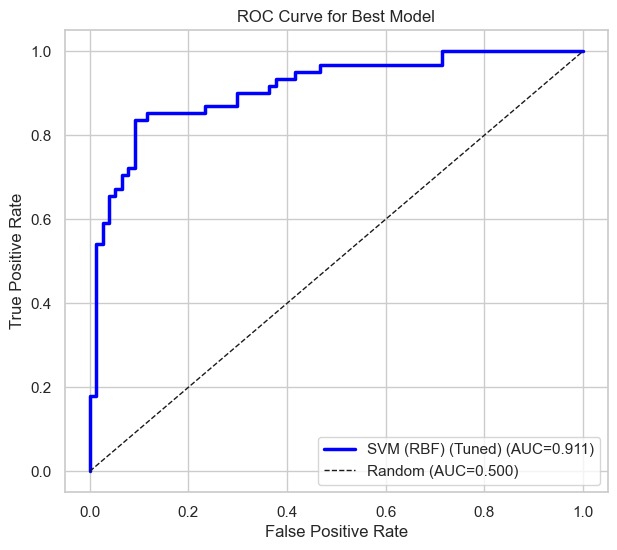

In [49]:
print(f"Best model overall: {best_name}")
print(f"Test Accuracy: {best_result['test_acc']:.4f}")
print(f"ROC-AUC:       {best_result['auc']:.4f}")
print("\nClassification Report for Best Model:")
print(classification_report(y_test, best_result['y_pred'], target_names=['Rejected (0)', 'Approved (1)']))
print("\nConfusion Matrix for Best Model:")
cm = confusion_matrix(y_test, best_result['y_pred'])
print(cm)
print("\nNormalised Confusion Matrix for Best Model:")
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
print(cm_norm)
print("\nROC Curve for Best Model:")
fpr, tpr, _ = roc_curve(y_test, best_result['y_proba'])
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='blue', lw=2.5, label=f'{best_name} (AUC={best_result["auc"]:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC=0.500)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Best Model')
plt.legend()
plt.show()